In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("ufc_fighter_details.csv")

df.head()

,FIRST,LAST,NICKNAME,URL
0,Tom,Aaron,NaN,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny,Abbadi,The Assassin,http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman,Abbasov,Bayraktar,http://ufcstats.com/fighter-details/59a9d6dac6...
3,David,Abbott,Tank,http://ufcstats.com/fighter-details/b361180739...
4,Hamdy,Abdelwahab,The Hammer,http://ufcstats.com/fighter-details/3329d692ae...


In [3]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(4422, 4)
Index(['FIRST', 'LAST', 'NICKNAME', 'URL'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 4422 entries, 0 to 4421
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   FIRST     4406 non-null   str  
 1   LAST      4422 non-null   str  
 2   NICKNAME  2442 non-null   str  
 3   URL       4422 non-null   str  
dtypes: str(4)
memory usage: 439.3 KB
None
        FIRST  ...                                                URL
count    4406  ...                                               4422
unique   2047  ...                                               4422
top     Chris  ...  http://ufcstats.com/fighter-details/93fe7332d1...
freq       58  ...                                                  1

[4 rows x 4 columns]


In [5]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.ffill()

In [7]:
print(df.head())
print(df.columns)

     FIRST  ...                                                URL
0      Tom  ...  http://ufcstats.com/fighter-details/93fe7332d1...
1    Danny  ...  http://ufcstats.com/fighter-details/15df64c02b...
2  Nariman  ...  http://ufcstats.com/fighter-details/59a9d6dac6...
3    David  ...  http://ufcstats.com/fighter-details/b361180739...
4    Hamdy  ...  http://ufcstats.com/fighter-details/3329d692ae...

[5 rows x 4 columns]
Index(['FIRST', 'LAST', 'NICKNAME', 'URL'], dtype='str')


In [8]:
le = LabelEncoder()

if 'stance' in df.columns:
    df['stance'] = le.fit_transform(df['stance'])

In [11]:
print(df.columns.tolist())

['first', 'last', 'nickname', 'url']


In [12]:
for col in df.columns:
    print(col)

first
last
nickname
url


In [13]:
print(df.columns.tolist())

['first', 'last', 'nickname', 'url']


In [15]:
missing = [col for col in features if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['height', 'weight', 'reach', 'stance', 'wins', 'losses']


In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


In [18]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



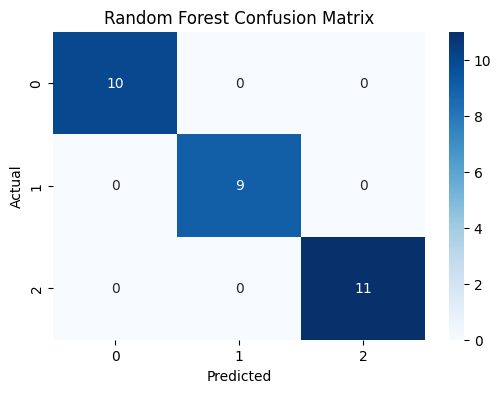

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

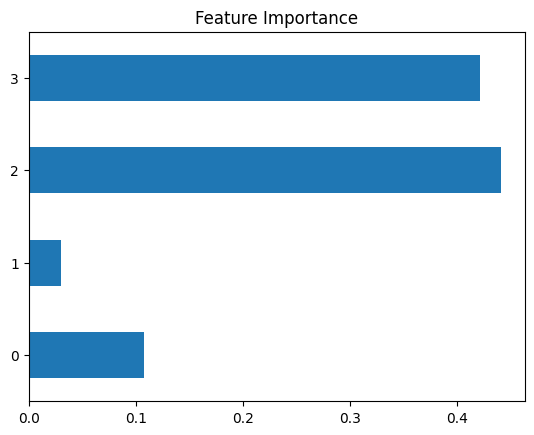

In [22]:
feat_importance = pd.Series(importances)
feat_importance.plot(kind='barh', title="Feature Importance")
plt.show()

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0
